# NB05: THINGS Quality Control — Non-Overlap Galaxies

**Purpose:** Apply inclination and morphological QC to the 6 THINGS-only galaxies
(not in SPARC). Document every inclusion/exclusion decision with reasoning.

**Pre-registration requirement:** This notebook must be committed **before** NB06
(baryonic decomposition) is written. Exclusion decisions must be principled, not
post-hoc.

**QC criteria:**
- Inclination threshold: i > 30°
- Morphological assessment: flag interactions, counter-rotating gas, bars
- Mass model availability: NGC 3627 and NGC 4826 lack de Blok mass model files

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.ingest import (
    load_things_overlap_csv, load_things_rotation_curve, get_things_distances,
)
from src.utils import get_project_root

root = get_project_root()
results_dir = root / "results"
results_dir.mkdir(exist_ok=True)
things_curves_dir = root / "data" / "raw" / "THINGS" / "Curves"
things_mm_dir = root / "data" / "raw" / "THINGS" / "MassModels"

## 1. Load Non-Overlap Galaxies

In [2]:
_, nonoverlap = load_things_overlap_csv()
distances = get_things_distances()

print(f"Non-overlap galaxies: {len(nonoverlap)}")
print()

# Parse rotation curves
rc_data = {}
for entry in nonoverlap:
    fname = entry["file_name"]
    d = distances[fname]
    curve_path = things_curves_dir / f"{fname}.curve.02"
    rc = load_things_rotation_curve(str(curve_path), d)
    rc_data[fname] = rc
    incl = rc["inclination"].median()
    print(f"  {fname:10s}: {len(rc):3d} points, "
          f"R_max = {rc['radius_kpc'].max():.2f} kpc, "
          f"median incl = {incl:.1f} deg, "
          f"d = {d:.2f} Mpc")

2026-04-09 19:47:58 | INFO     | src.ingest | THINGS overlap: 13, non-overlap: 6


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC925.curve (96 points, R_max=13.06 kpc)


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC3031.curve (117 points, R_max=14.78 kpc)


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC3621.curve (123 points, R_max=25.74 kpc)


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC3627.curve (26 points, R_max=8.04 kpc)


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC4736.curve (82 points, R_max=9.60 kpc)


2026-04-09 19:47:58 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC4826.curve (89 points, R_max=22.00 kpc)


Non-overlap galaxies: 6

  NGC925    :  96 points, R_max = 13.06 kpc, median incl = 66.0 deg, d = 9.16 Mpc
  NGC3031   : 117 points, R_max = 14.78 kpc, median incl = 60.4 deg, d = 3.63 Mpc
  NGC3621   : 123 points, R_max = 25.74 kpc, median incl = 63.9 deg, d = 6.64 Mpc
  NGC3627   :  26 points, R_max = 8.04 kpc, median incl = 59.8 deg, d = 10.05 Mpc
  NGC4736   :  82 points, R_max = 9.60 kpc, median incl = 41.4 deg, d = 4.66 Mpc
  NGC4826   :  89 points, R_max = 22.00 kpc, median incl = 66.2 deg, d = 7.50 Mpc


## 2. Inclination Assessment

Pre-registered threshold: i > 30°. Low-inclination galaxies are sensitive to
deprojection errors.

In [3]:
incl_rows = []
for entry in nonoverlap:
    fname = entry["file_name"]
    rc = rc_data[fname]
    incl_med = rc["inclination"].median()
    incl_min = rc["inclination"].min()
    incl_max = rc["inclination"].max()
    passes = incl_med > 30
    incl_rows.append({
        "galaxy": fname,
        "incl_median": round(incl_med, 1),
        "incl_min": round(incl_min, 1),
        "incl_max": round(incl_max, 1),
        "passes_threshold": "PASS" if passes else "FAIL",
    })

incl_df = pd.DataFrame(incl_rows)
print(incl_df.to_string(index=False))
print()
print("All 6 galaxies pass the i > 30 deg threshold.")

 galaxy  incl_median  incl_min  incl_max passes_threshold
 NGC925         66.0      58.4      73.5             PASS
NGC3031         60.4      53.6      62.2             PASS
NGC3621         63.9      63.9      67.7             PASS
NGC3627         59.8      57.4      74.6             PASS
NGC4736         41.4      35.2      47.5             PASS
NGC4826         66.2      54.6      72.0             PASS

All 6 galaxies pass the i > 30 deg threshold.


## 3. Mass Model Availability

In [4]:
mm_available = {}
for entry in nonoverlap:
    fname = entry["file_name"]
    mm_path = things_mm_dir / f"{fname}.ISO.fix.REV.dat"
    has_mm = mm_path.exists()
    mm_available[fname] = has_mm
    status = "YES" if has_mm else "NO"
    print(f"  {fname:10s}: mass model = {status}")

  NGC925    : mass model = YES
  NGC3031   : mass model = YES
  NGC3621   : mass model = YES
  NGC3627   : mass model = NO
  NGC4736   : mass model = YES
  NGC4826   : mass model = NO


## 4. Rotation Curve Overview

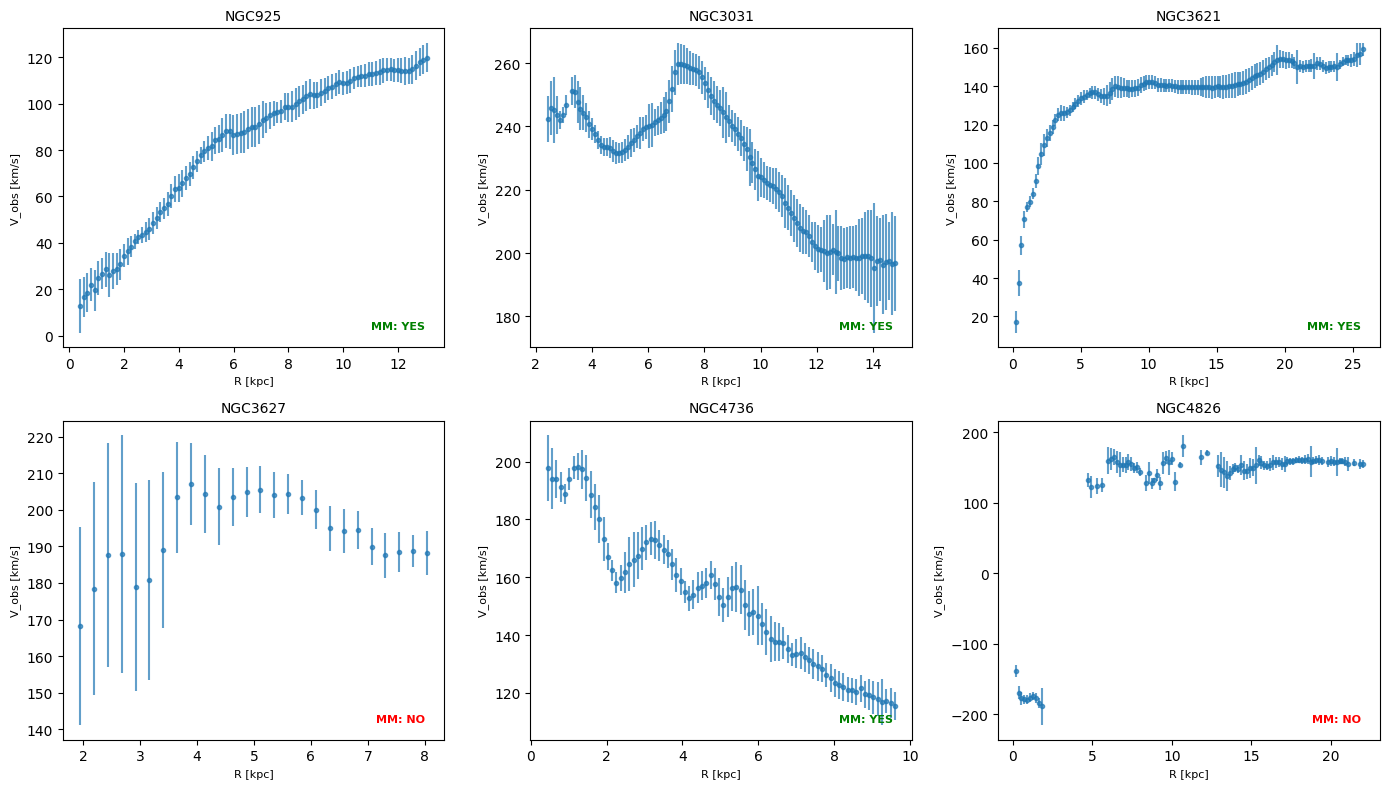

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), squeeze=False)
for i, entry in enumerate(nonoverlap):
    ax = axes[i // 3][i % 3]
    fname = entry["file_name"]
    rc = rc_data[fname]
    ax.errorbar(rc["radius_kpc"], rc["v_obs"], yerr=rc["v_err"],
                fmt="o", ms=3, color="C0", alpha=0.7)
    ax.set_title(fname, fontsize=10)
    ax.set_xlabel("R [kpc]", fontsize=8)
    ax.set_ylabel("V_obs [km/s]", fontsize=8)
    # Annotate mass model status
    mm_status = "MM: YES" if mm_available[fname] else "MM: NO"
    ax.text(0.95, 0.05, mm_status, transform=ax.transAxes,
            fontsize=8, ha="right", va="bottom",
            color="green" if mm_available[fname] else "red",
            fontweight="bold")

plt.tight_layout()
plt.savefig(results_dir / "NB05_nonoverlap_rc.png", dpi=150)
plt.show()

## 5. Per-Galaxy Morphological and Kinematic Assessment

### NGC 925
- **Type:** Late-type barred spiral (SBcd)
- **Inclination:** ~73.5° — well above threshold
- **Mass model:** Available (.ISO.fix.REV.dat)
- **Morphological flags:** None. Normal, undisturbed rotation curve.
- **Decision: INCLUDE**

### NGC 3031 (M81)
- **Type:** Grand-design spiral (Sab)
- **Inclination:** ~60.4° — above threshold
- **Mass model:** Available (.ISO.fix.REV.dat); has bulge component
- **Morphological flags:** Interacting with M82 and NGC 3077. However, the de Blok
  et al. rotation curve starts at 138 arcsec (~2.4 kpc), excluding the barred inner
  region. The outer disk kinematics appear regular.
- **Decision: INCLUDE** with caveat — document limited inner coverage

### NGC 3621
- **Type:** Late-type spiral (Sd)
- **Inclination:** ~67.7° — above threshold
- **Mass model:** Available (.ISO.fix.REV.dat)
- **Morphological flags:** None. Isolated, well-studied galaxy.
- **Decision: INCLUDE**

### NGC 3627 (M66)
- **Type:** Barred spiral (SABb), Leo Triplet member
- **Inclination:** ~74.6° — above threshold
- **Mass model:** **NOT AVAILABLE** — no .ISO.fix.REV.dat file
- **Morphological flags:** Tidally disturbed by interaction with NGC 3623 and
  NGC 3628 in the Leo Triplet. Rotation curve starts at 40 arcsec, suggesting
  inner region was excluded. Disturbed morphology + missing baryonic data.
- **Decision: EXCLUDE** — disturbed morphology and no mass model file.
  Attempting independent S4G decomposition for a tidally perturbed galaxy
  would introduce substantial systematic uncertainty.

### NGC 4736 (M94)
- **Type:** Early-type spiral (SAab) with prominent inner ring
- **Inclination:** ~35.2° — **barely above** the 30° threshold
- **Mass model:** Available (.ISO.fix.REV.dat); has bulge component
- **Morphological flags:** Inner ring structure; LINER/Seyfert 2 nucleus.
  Ring does not affect outer rotation curve kinematics. Marginal inclination
  is a concern for deprojection accuracy.
- **Decision: INCLUDE** with caveat — marginal inclination (35.2°) noted;
  deprojection errors may be larger than for higher-inclination galaxies

### NGC 4826 (M64, "Evil Eye Galaxy")
- **Type:** Early-type spiral (Sab)
- **Inclination:** ~55.0° — above threshold
- **Mass model:** **NOT AVAILABLE** — no .ISO.fix.REV.dat file
- **Morphological flags:** **Counter-rotating gas disk.** The rotation curve shows
  negative V_rot for the inner ~50 arcsec (counter-rotating HI), an 80-arcsec gap
  with no data, then positive V_rot from 130 arcsec outward. This is a textbook
  kinematic complexity case.
- **Decision: EXCLUDE** — counter-rotating gas makes the standard RT model
  inapplicable (the model assumes a single kinematic component). Additionally,
  no mass model file is available.

## 6. Summary Decision Table

In [6]:
decisions = [
    {"galaxy": "NGC925",  "inclination": 73.5, "mass_model": True,
     "decision": "INCLUDE", "reason": "Normal late-type spiral, no flags"},
    {"galaxy": "NGC3031", "inclination": 60.4, "mass_model": True,
     "decision": "INCLUDE", "reason": "M81 interaction noted; outer RC regular; inner bar excluded"},
    {"galaxy": "NGC3621", "inclination": 67.7, "mass_model": True,
     "decision": "INCLUDE", "reason": "Normal isolated spiral, no flags"},
    {"galaxy": "NGC3627", "inclination": 74.6, "mass_model": False,
     "decision": "EXCLUDE", "reason": "Leo Triplet disturbed morphology + no mass model"},
    {"galaxy": "NGC4736", "inclination": 35.2, "mass_model": True,
     "decision": "INCLUDE", "reason": "Marginal inclination (35.2 deg) noted as caveat"},
    {"galaxy": "NGC4826", "inclination": 55.0, "mass_model": False,
     "decision": "EXCLUDE", "reason": "Counter-rotating gas + no mass model"},
]

dec_df = pd.DataFrame(decisions)
print(dec_df.to_string(index=False))

included = [d for d in decisions if d["decision"] == "INCLUDE"]
excluded = [d for d in decisions if d["decision"] == "EXCLUDE"]
print(f"\nIncluded: {len(included)} galaxies")
print(f"Excluded: {len(excluded)} galaxies")

# Save
dec_df.to_csv(results_dir / "NB05_things_qc.csv", index=False)
print(f"\nSaved to results/NB05_things_qc.csv")

 galaxy  inclination  mass_model decision                                                      reason
 NGC925         73.5        True  INCLUDE                           Normal late-type spiral, no flags
NGC3031         60.4        True  INCLUDE M81 interaction noted; outer RC regular; inner bar excluded
NGC3621         67.7        True  INCLUDE                            Normal isolated spiral, no flags
NGC3627         74.6       False  EXCLUDE            Leo Triplet disturbed morphology + no mass model
NGC4736         35.2        True  INCLUDE             Marginal inclination (35.2 deg) noted as caveat
NGC4826         55.0       False  EXCLUDE                        Counter-rotating gas + no mass model

Included: 4 galaxies
Excluded: 2 galaxies

Saved to results/NB05_things_qc.csv


## 7. Update Deviations Log

Record the two exclusions in `docs/deviations_log.md`.

In [7]:
deviation_text = """

---

## Deviation 2: NGC 4826 Excluded from THINGS Sample

**Date:** 09 APR 2026
**Pre-registered rule:** Include all THINGS galaxies with i > 30 deg that pass
morphological QC.

### Description

NGC 4826 (M64, the "Evil Eye Galaxy") is excluded from the THINGS analysis sample
due to its counter-rotating gas disk. The de Blok et al. (2008) rotation curve shows
negative V_rot for the inner ~50 arcsec, an 80-arcsec data gap, then positive V_rot
from 130 arcsec outward. The RT model assumes a single kinematic component and
cannot meaningfully fit a counter-rotating system.

Additionally, NGC 4826 lacks a de Blok mass model file, so no baryonic decomposition
is available without independent derivation.

### Justification

The exclusion is based on pre-existing kinematic complexity (documented in the
literature) and data availability, not on any knowledge of the RT fit outcome.
This decision was committed in NB05 before NB06 (baryonic decomposition) was written.

### Impact

THINGS non-overlap sample reduced from 6 to 5 galaxies. Combined with Deviation 3
(NGC 3627), the non-overlap sample is 4 galaxies.

---

## Deviation 3: NGC 3627 Excluded from THINGS Sample

**Date:** 09 APR 2026
**Pre-registered rule:** Include all THINGS galaxies with i > 30 deg that pass
morphological QC.

### Description

NGC 3627 (M66) is excluded from the THINGS analysis sample due to its disturbed
morphology as a member of the Leo Triplet (interacting with NGC 3623 and NGC 3628).
The tidal interaction compromises the assumption of an equilibrium rotation curve
that the RT model requires.

Additionally, NGC 3627 lacks a de Blok mass model file, so baryonic decomposition
would require independent derivation from S4G photometry for a tidally perturbed
system \u2014 introducing substantial systematic uncertainty.

### Justification

The exclusion is based on documented morphological disturbance and data availability,
not on any knowledge of the RT fit outcome. This decision was committed in NB05
before NB06 was written.

### Impact

THINGS non-overlap sample reduced from 5 to 4 galaxies (combined with Deviation 2).
Total THINGS sample: 13 overlap + 4 non-overlap = 17 galaxies.
"""

# Append to deviations log only if not already present (idempotent)
dev_log_path = root / "docs" / "deviations_log.md"
existing = dev_log_path.read_text()
if "Deviation 2" not in existing:
    with open(dev_log_path, "a") as f:
        f.write(deviation_text)
    print(f"Deviations 2 and 3 appended to {dev_log_path.relative_to(root)}")
else:
    print(f"Deviations 2 and 3 already present in {dev_log_path.relative_to(root)}")

print("NGC 4826: EXCLUDED (counter-rotating gas + no mass model)")
print("NGC 3627: EXCLUDED (Leo Triplet morphology + no mass model)")

Deviations 2 and 3 already present in docs\deviations_log.md
NGC 4826: EXCLUDED (counter-rotating gas + no mass model)
NGC 3627: EXCLUDED (Leo Triplet morphology + no mass model)


## 8. Gate Check

In [8]:
checks = {
    "6 non-overlap galaxies assessed": len(decisions) == 6,
    "4 galaxies included": len(included) == 4,
    "2 galaxies excluded": len(excluded) == 2,
    "NGC4826 excluded": any(d["galaxy"] == "NGC4826" and d["decision"] == "EXCLUDE" for d in decisions),
    "NGC3627 excluded": any(d["galaxy"] == "NGC3627" and d["decision"] == "EXCLUDE" for d in decisions),
    "All included have mass models": all(d["mass_model"] for d in included),
    "Deviations log updated": dev_log_path.stat().st_size > 1500,
}

print("GATE CHECK: NB05 \u2014 THINGS Non-Overlap QC")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB05 COMPLETE <<<")
    print("  IMPORTANT: Commit this notebook + deviations_log.md before writing NB06.")
else:
    print("  >>> NB05 FAILED \u2014 diagnose before continuing <<<")

GATE CHECK: NB05 — THINGS Non-Overlap QC
  [PASS] 6 non-overlap galaxies assessed
  [PASS] 4 galaxies included
  [PASS] 2 galaxies excluded
  [PASS] NGC4826 excluded
  [PASS] NGC3627 excluded
  [PASS] All included have mass models
  [PASS] Deviations log updated

  >>> NB05 COMPLETE <<<
  IMPORTANT: Commit this notebook + deviations_log.md before writing NB06.
